# Telco Customer Churn Prediction

## Problem Statement
Customer churn costs telecom companies significant revenue. This project builds a 
binary classification model to predict which customers are likely to churn, enabling 
proactive retention strategies.

## Dataset
- **Source:** IBM Telco Customer Churn (Kaggle)
- **Size:** 7,043 customers, 21 features
- **Target:** `Churn` — whether a customer left within the last month

## Approach
1. Exploratory Data Analysis to understand churn drivers
2. Feature Engineering to extract signal
3. Three models compared: Logistic Regression, Random Forest, LightGBM
4. Evaluation using ROC-AUC, PR-AUC, and F1 at an optimised threshold

## Key Findings
All three models performed comparably (~0.862 Test ROC-AUC). Random Forest narrowly 
led on test AUC, though all models were within 0.001 of each other — suggesting the 
dataset has a performance ceiling near this level without further feature work.  
Month-to-month contracts and low tenure were the strongest churn predictors.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

import lightgbm as lgb
import shap
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, roc_auc_score, roc_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, average_precision_score, precision_recall_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# Display Markdown
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

In [35]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 5

In [36]:
df_train = pd.read_csv('../src/WA_Fn-UseC_-Telco-Customer-Churn.csv')

## Inspecting Dataset

In [37]:
display(Markdown(f"**Rows:** {df_train.shape[0]}, **Columns:** {df_train.shape[1]}"))
display(df_train.head())

**Rows:** 7043, **Columns:** 21

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [38]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [39]:
df_train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
#Displaying Missing Values count
display(Markdown("### <span style='color:#7197e9; font-weight:600;'>Missing Values</span>"))
display(df_train.isnull().sum().sort_values(ascending=False))

#Displaying duplicate rows
display(Markdown("### <span style='color:#7197e9; font-weight:600;'>Duplicate Rows</span>"))
display(Markdown(f"**Total Duplicates:** {df_train.duplicated().sum()}"))

# Displaying nique values per column
display(Markdown("### <span style='color:#7197e9; font-weight:600;'>Unique Values</span>"))
display(df_train.nunique().sort_values(ascending=False))

#Differentiating between categorical and numerical columns
categorical_cols = df_train.select_dtypes(include=['object']).columns.tolist()
binary_cols = [col for col in categorical_cols if df_train[col].nunique() == 2]
numerical_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

display(Markdown("### <span style='color:#7197e9; font-weight:600;'>Categorical Columns</span>"))
display(categorical_cols)

display(Markdown("### <span style='color:#7197e9; font-weight:600;'>Binary Columns</span>"))
display(binary_cols)

display(Markdown("### <span style='color:#7197e9; font-weight:600;'>Numerical Columns</span>"))
display(numerical_cols)

### <span style='color:#7197e9; font-weight:600;'>Missing Values</span>

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

### <span style='color:#7197e9; font-weight:600;'>Duplicate Rows</span>

**Total Duplicates:** 0

### <span style='color:#7197e9; font-weight:600;'>Unique Values</span>

customerID          7043
TotalCharges        6531
MonthlyCharges      1585
tenure                73
PaymentMethod          4
DeviceProtection       3
Contract               3
StreamingMovies        3
StreamingTV            3
TechSupport            3
OnlineBackup           3
OnlineSecurity         3
InternetService        3
MultipleLines          3
gender                 2
PhoneService           2
PaperlessBilling       2
Dependents             2
Partner                2
SeniorCitizen          2
Churn                  2
dtype: int64

### <span style='color:#7197e9; font-weight:600;'>Categorical Columns</span>

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn']

### <span style='color:#7197e9; font-weight:600;'>Binary Columns</span>

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'PaperlessBilling',
 'Churn']

### <span style='color:#7197e9; font-weight:600;'>Numerical Columns</span>

['SeniorCitizen', 'tenure', 'MonthlyCharges']

## Data Cleaning

### Cleaning Decisions
- `TotalCharges` is stored as a string despite being numeric — 11 rows have blank 
  values which we impute with the median (not mean, to avoid skew sensitivity).
- `No internet service` and `No phone service` are consolidated to `No` since they 
  are functionally equivalent and reduce cardinality.
- `customerID` is dropped as it is a unique identifier with no predictive value.

In [41]:
#Cleaning string columns
df_train = df_train.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

#Dropping customerID as it is not useful for modeling
df_train = df_train.drop(columns=['customerID'])

#Redo column types
# 3. Recompute column types
categorical_cols = df_train.select_dtypes(include=['object']).columns.tolist()
binary_cols = [col for col in categorical_cols if df_train[col].nunique() == 2]

#Target encoding
target = 'Churn'
target_map = {'Yes': 1, 'No': 0}

df_train[target] = df_train[target].map(target_map).astype(int)

#Converting TotalCharges to numeric and filling missing values with median
df_train['TotalCharges'] = pd.to_numeric(df_train['TotalCharges'], errors='coerce')
df_train['TotalCharges'] = df_train['TotalCharges'].fillna(df_train['TotalCharges'].median())

#Converting Binary Columns
for col in binary_cols:
    if set(df_train[col].unique()) == {'Yes', 'No'}:
        df_train[col] = df_train[col].map({'Yes': 1, 'No': 0})
    elif set(df_train[col].unique()) == {'Male', 'Female'}:
        df_train[col] = df_train[col].map({'Male': 1, 'Female': 0})

#Cleaning up dependant data if no phone service
df_train['MultipleLines'] = df_train['MultipleLines'].replace({'No phone service': 'No'})

#Same but for internet service
internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in internet_cols:
    df_train[col] = df_train[col].replace({'No internet service': 'No'})

#Tenure shouldn't be negative
assert (df_train['tenure'] >= 0).all()

# Monthly Charges shouldn't be negative
assert (df_train['MonthlyCharges'] > 0).all()

In [42]:
print(f"Churn rate: {df_train['Churn'].mean():.2%}")

Churn rate: 26.54%


## Exploratory Data Analysis (EDA)

In [43]:
print(df_train['Churn'].value_counts())
print(df_train['Churn'].unique())

Churn
0    5174
1    1869
Name: count, dtype: int64
[0 1]


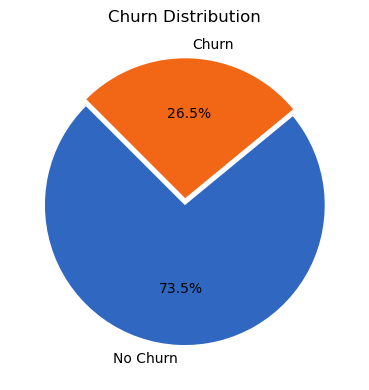

In [44]:
fig, ax = plt.subplots(figsize=(5,4))
churn_counts = df_train['Churn'].value_counts(normalize=True).sort_index()

labels = ['No Churn', 'Churn']

ax.pie(
    churn_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=135,
    explode=[0,0.05],
    colors=["#2f67c1", "#f16716"]
)

ax.set_title('Churn Distribution')
plt.tight_layout()
#plt.savefig('../outputs/figures/churn_distribution.png')
plt.show()

<Axes: xlabel='Churn', ylabel='count'>

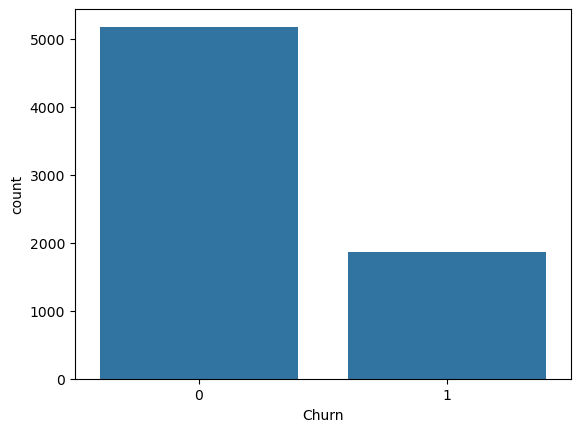

In [45]:
sns.countplot(x='Churn', data=df_train)

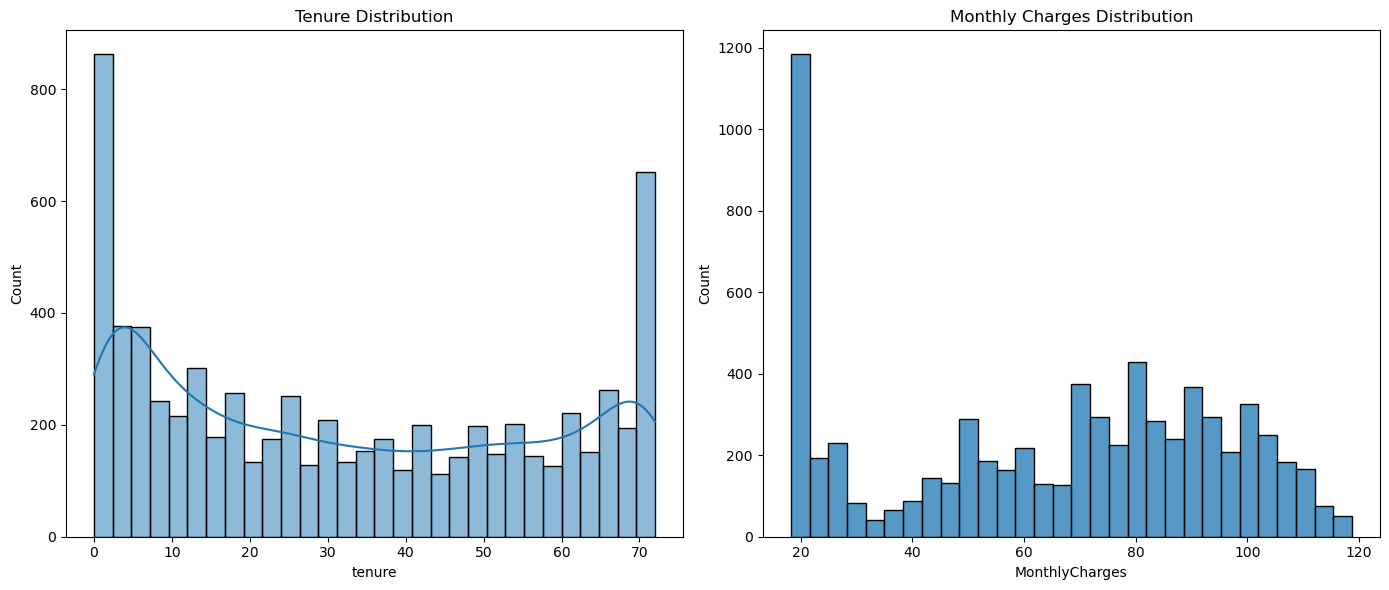

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df_train['tenure'], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Tenure Distribution")

sns.histplot(df_train['MonthlyCharges'], bins=30, ax=axes[1])
axes[1].set_title("Monthly Charges Distribution")

plt.tight_layout()
plt.show()

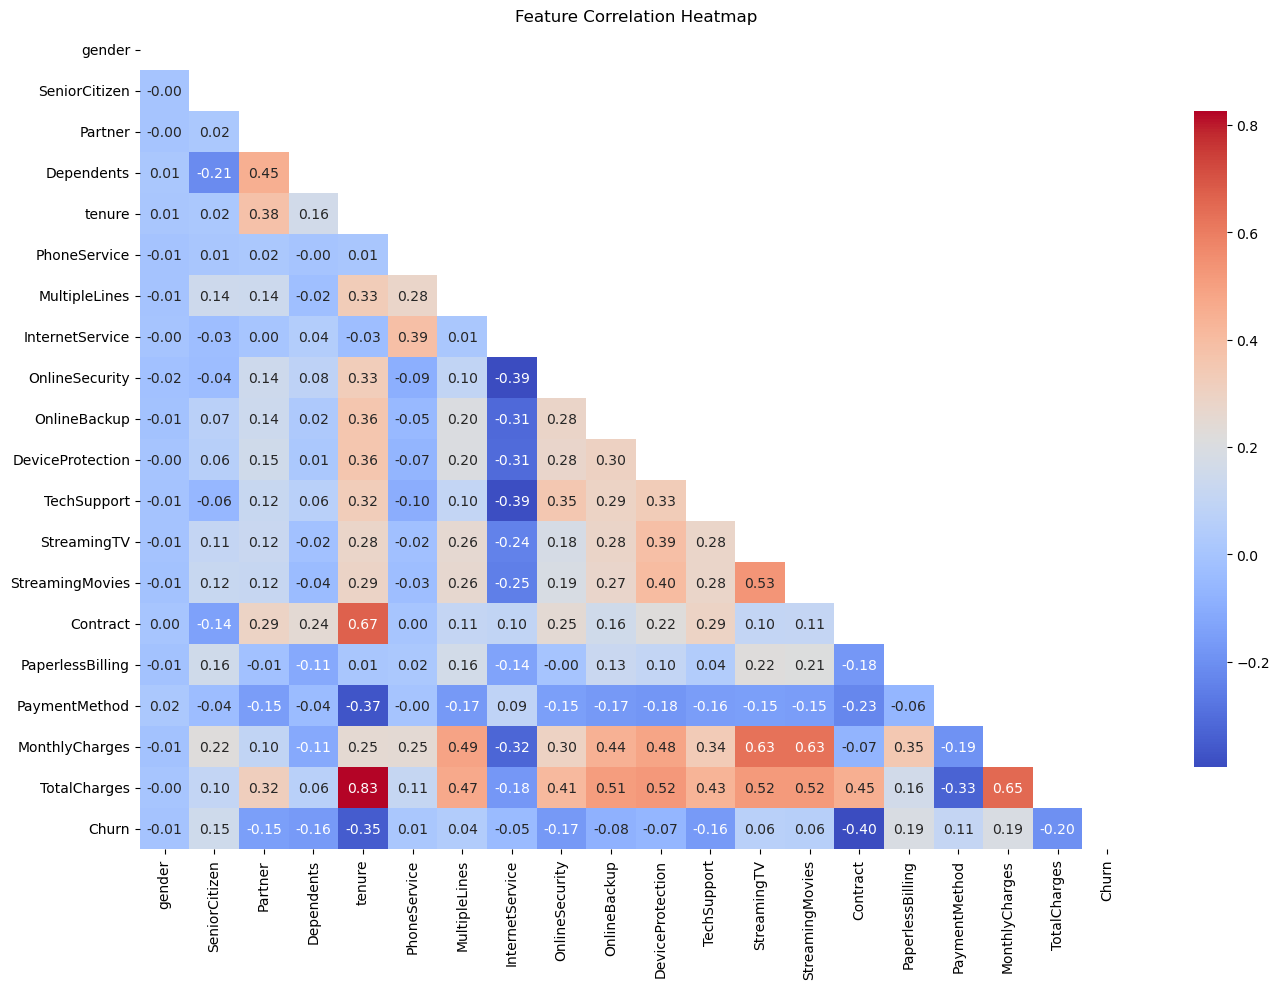

In [47]:
#Correlation heatmap
df_corr = df_train.copy()
for c in df_corr.select_dtypes("object").columns:
    df_corr[c] = LabelEncoder().fit_transform(df_corr[c])
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

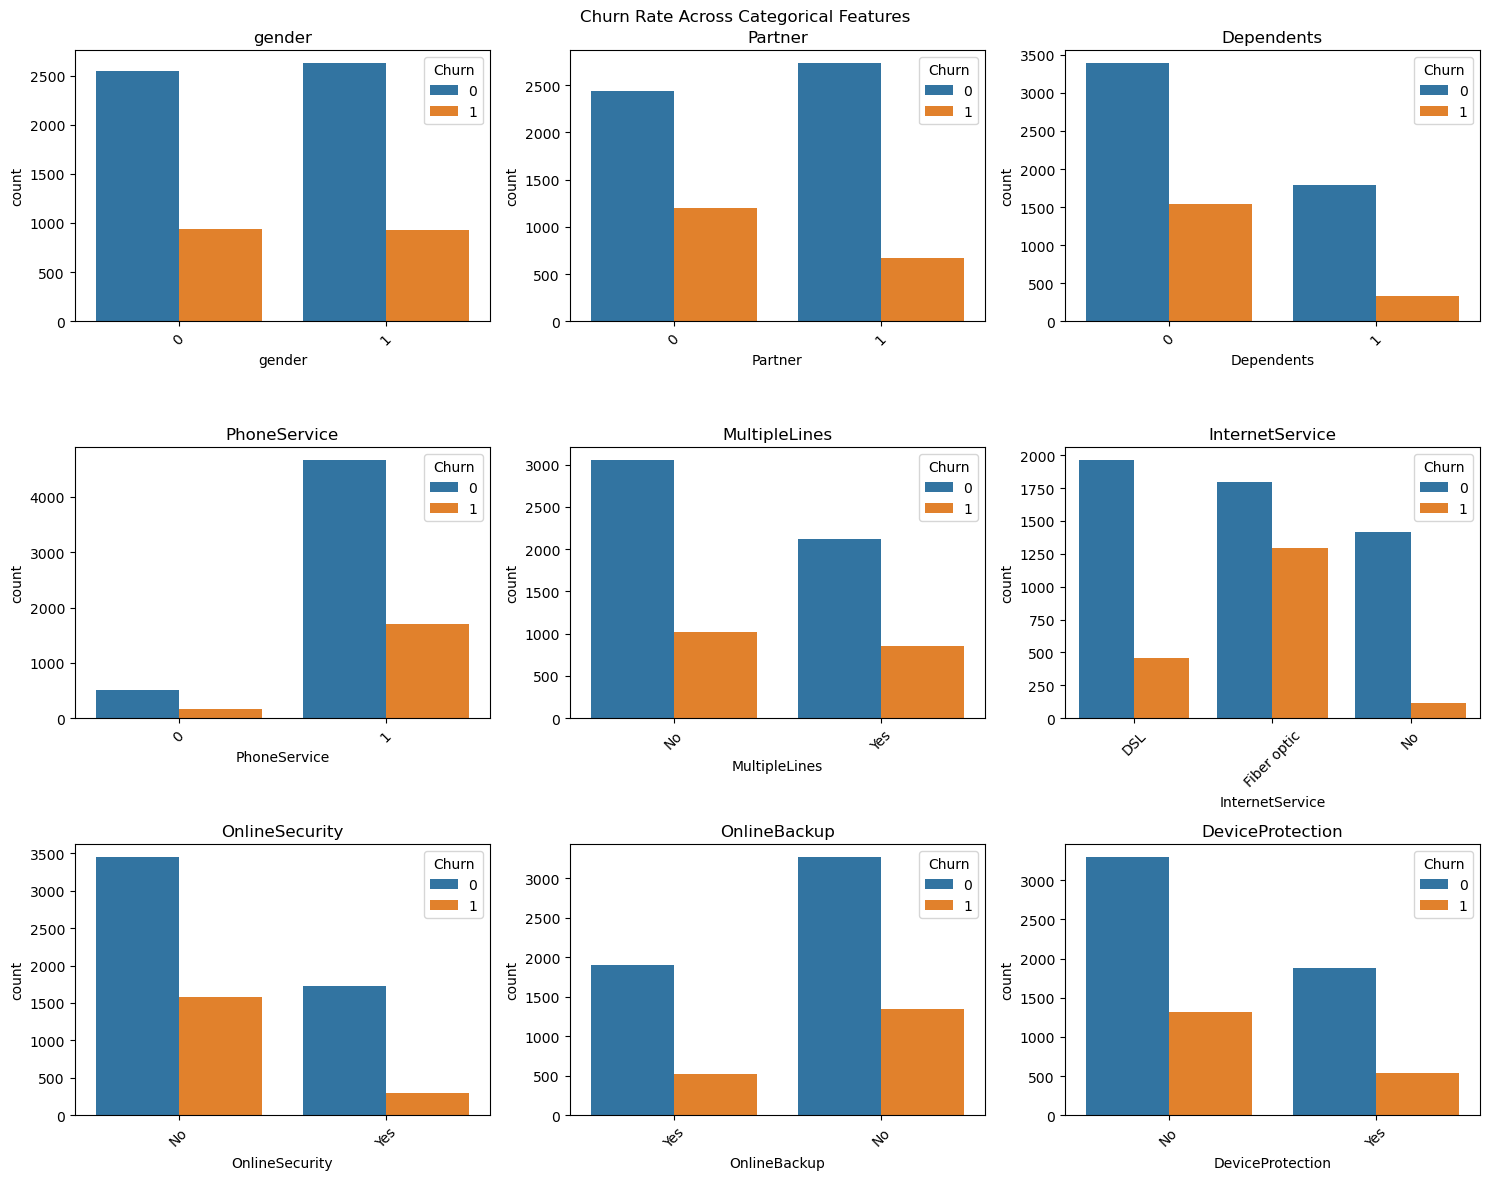

In [48]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols[:9]): #limits it to 9 plots
    churn_rate = df_train.groupby(col)['Churn'].mean().sort_values()
    sns.countplot(x=col, hue='Churn', data=df_train, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Churn Rate Across Categorical Features', fontsize=12)
plt.tight_layout()
plt.show()

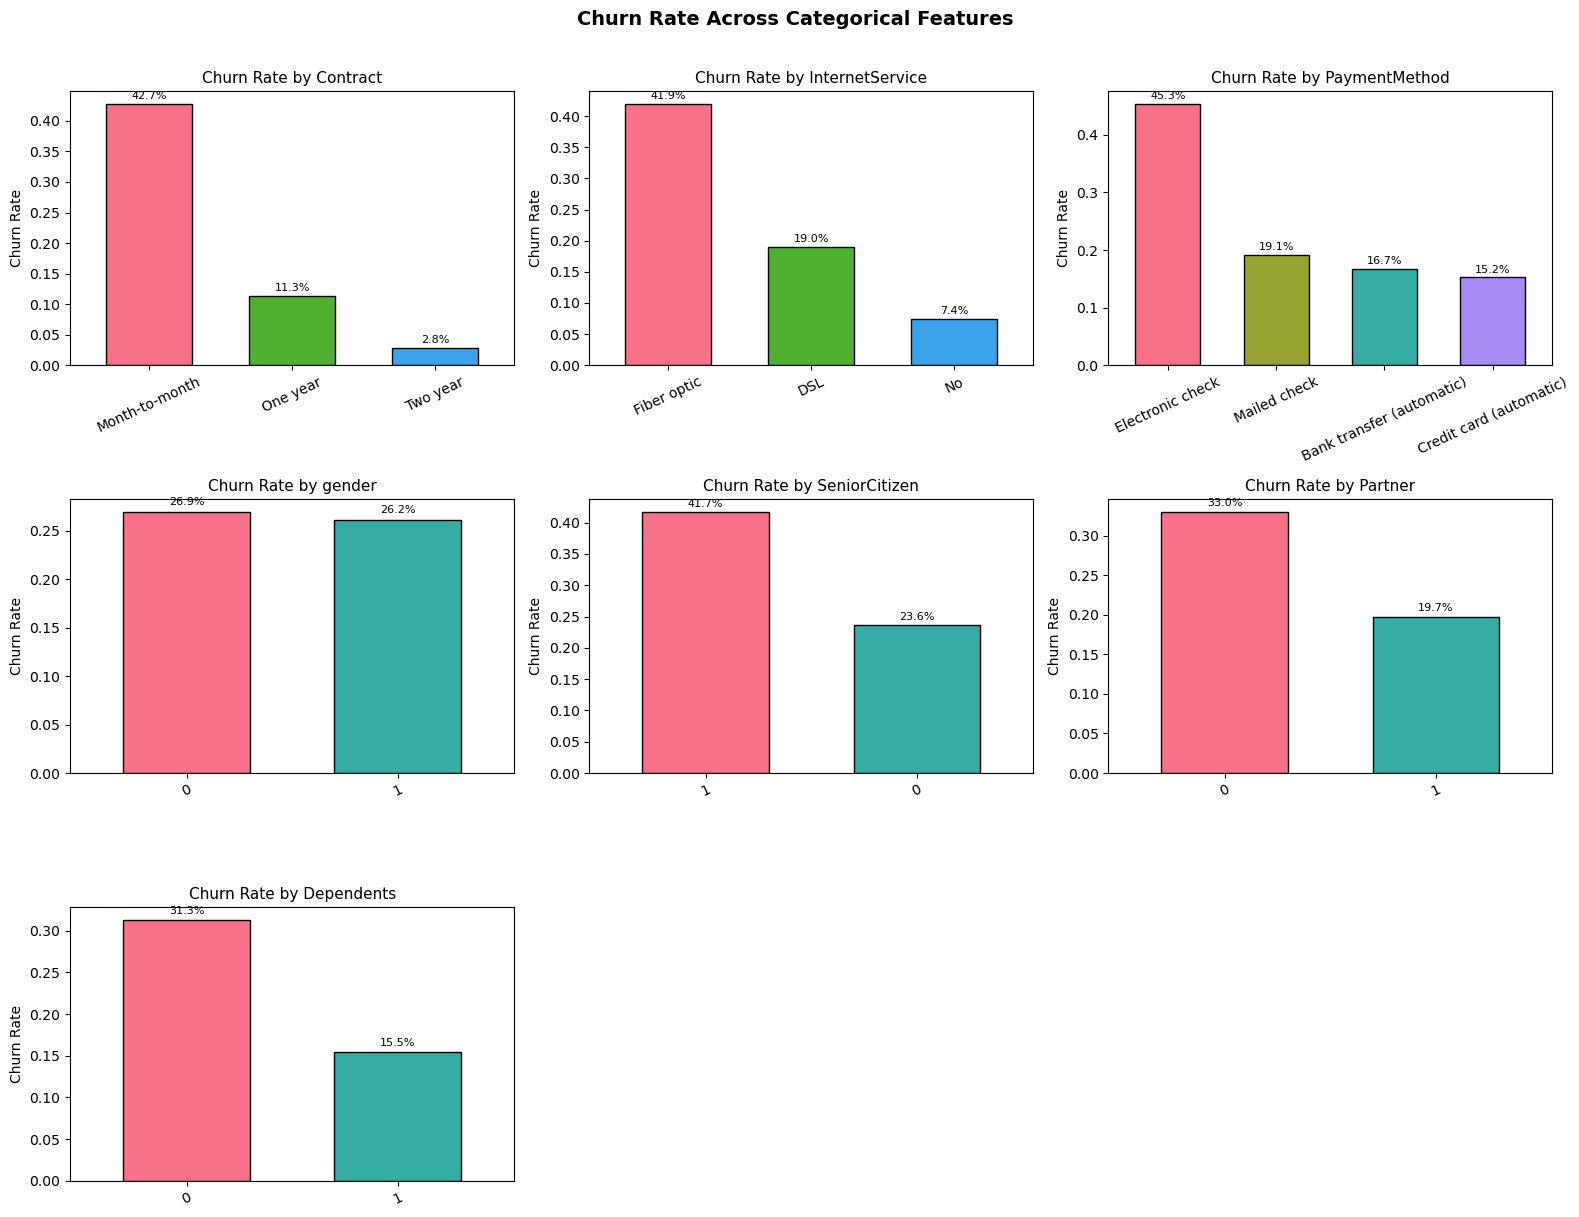

In [49]:
# Churn by contract type, internet service, payment method
cat_cols = ["Contract","InternetService","PaymentMethod","gender","SeniorCitizen","Partner","Dependents"]
fig, axes = plt.subplots(3, 3, figsize=(16,12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ct = df_train.groupby(col)["Churn"].mean().sort_values(ascending=False)
    ct.plot(kind="bar", ax=axes[i], color=sns.color_palette("husl", len(ct)),
            edgecolor="black", width=0.6)
    axes[i].set_title(f"Churn Rate by {col}", fontsize=11)
    axes[i].set_ylabel("Churn Rate")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=25)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                     f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=8)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle("Churn Rate Across Categorical Features", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/Feature_Importance.png', dpi=150, bbox_inches='tight')
plt.show()

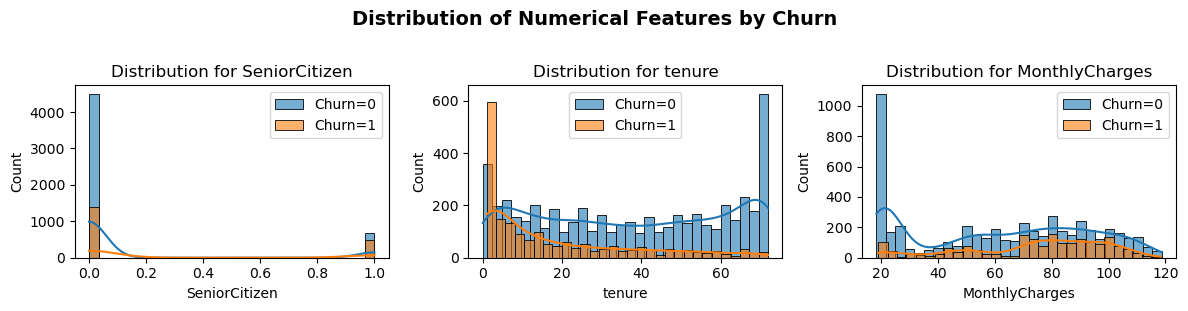

In [50]:
#Now doing numeric distributions by churn
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, col in zip(axes, numerical_cols):
    for label, grp in df_train.groupby('Churn'):
        sns.histplot(grp[col], bins=30, kde=True, ax=ax, label=f"Churn={label}", alpha=0.6)
    ax.set_title(f"Distribution for {col}")
    ax.set_xlabel(col)
    ax.legend()
plt.suptitle("Distribution of Numerical Features by Churn", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/Numerical_Features.png', dpi=150, bbox_inches='tight')
plt.show()

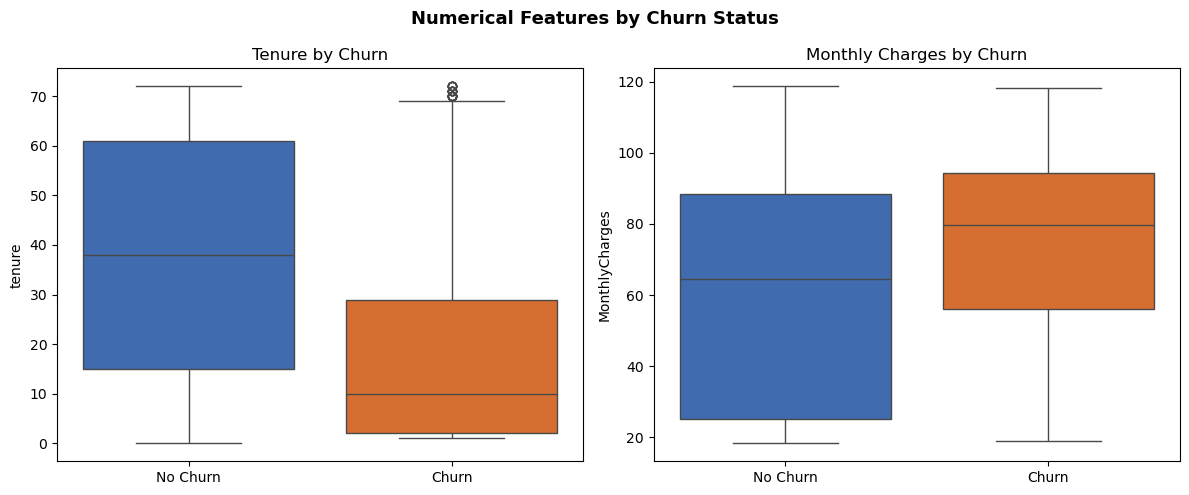

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Churn', y='tenure', data=df_train, ax=axes[0], palette=['#2f67c1', '#f16716'])
axes[0].set_title('Tenure by Churn')
axes[0].set_xticklabels(['No Churn', 'Churn'])
axes[0].set_xlabel('')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df_train, ax=axes[1], palette=['#2f67c1', '#f16716'])
axes[1].set_title('Monthly Charges by Churn')
axes[1].set_xticklabels(['No Churn', 'Churn'])
axes[1].set_xlabel('')

plt.suptitle('Numerical Features by Churn Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<Axes: xlabel='Contract', ylabel='Churn'>

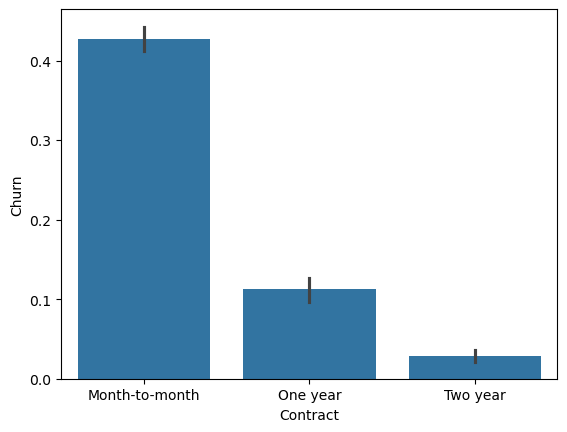

In [52]:
df_train['tenure_group'] = pd.cut(df_train['tenure'], bins=[0,12,24,48,72])
pd.crosstab(df_train['Contract'], df_train['Churn'], normalize='index')
sns.barplot(x='Contract', y='Churn', data=df_train)

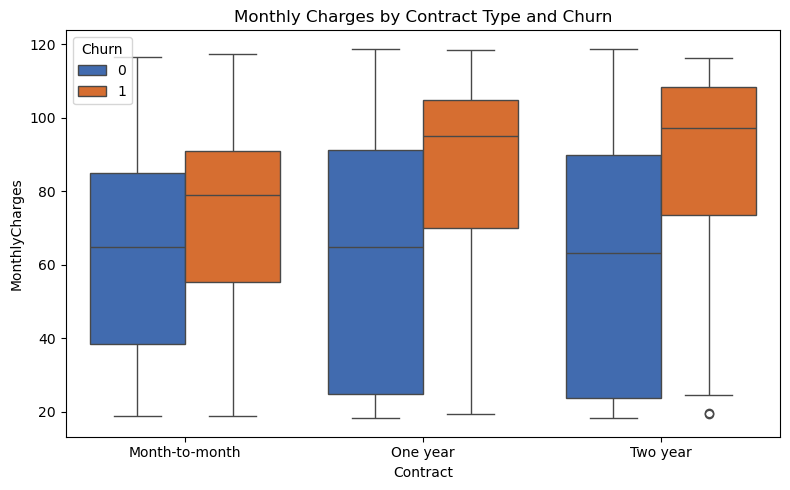

In [53]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='Contract', y='MonthlyCharges', hue='Churn', data=df_train, ax=ax, palette=['#2f67c1', '#f16716'])
ax.set_title('Monthly Charges by Contract Type and Churn')
plt.tight_layout()
plt.show()

## Feature Engineering

### Engineered Features
- `charges_per_tenure`: captures cost efficiency — high monthly charges relative to 
  tenure may signal customers who haven't yet found value.
- `total_services`: number of add-on services subscribed — more services may indicate 
  higher switching costs and lower churn risk.

In [54]:
df_model = df_train.copy()

df_model['charges_per_tenure'] = df_model['MonthlyCharges'] / (df_model['tenure'] + 1)
df_model['total_services'] = df_model[internet_cols + ['PhoneService', 'MultipleLines']].apply(pd.to_numeric, errors='coerce').sum(axis=1)

df_model = df_model.drop(columns=['tenure_group'], errors='ignore')

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 5634 | Test: 1409


## Modelling

Three models are trained using 5-fold Stratified Cross-Validation to handle class 
imbalance (~26% churn). `class_weight='balanced'` is used for LR and RF; 
`scale_pos_weight` is used for LightGBM. The best threshold is derived from the 
OOF PR curve rather than defaulting to 0.5.

In [55]:
##Logistic Regression

lr_scores = []
lr_models = []

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

for train_idx, val_idx in skf.split(X_train_scaled, y_train):
    X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    lr = LogisticRegression(
        max_iter=1000,
        tol=1e-4,
        class_weight='balanced',
        solver='liblinear',
        C=1.0,
        random_state=RANDOM_STATE)
    lr.fit(X_tr, y_tr)
    
    lr_preds = lr.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, lr_preds)

    lr_scores.append(score)
    pr = average_precision_score(y_val, lr_preds)
    lr_models.append(lr)

    print(f"Fold ROC:: {score} | PR-AUC: {pr:.4f}")

print(f"Mean ROC-AUC: {np.mean(lr_scores):.4f}")
print(f"Std ROC-AUC: {np.std(lr_scores):.4f}")

Fold ROC:: 0.8200705249381999 | PR-AUC: 0.6296
Fold ROC:: 0.8497830934031313 | PR-AUC: 0.6910
Fold ROC:: 0.8489772672192332 | PR-AUC: 0.6657
Fold ROC:: 0.8436557839580814 | PR-AUC: 0.6325
Fold ROC:: 0.8584843472599112 | PR-AUC: 0.6902
Mean ROC-AUC: 0.8442
Std ROC-AUC: 0.0130


In [56]:
#Random Forest

rf_scores = []
rf_models = []

rf_oof_preds = np.zeros(len(X_train))

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=2,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf.fit(X_tr, y_tr)
    
    rf_preds = rf.predict_proba(X_val)[:, 1]
    rf_oof_preds[val_idx] = rf_preds
    score = roc_auc_score(y_val, rf_preds)

    rf_scores.append(score)
    pr = average_precision_score(y_val, rf_preds)

    print(f"Fold ROC:: {score} | PR-AUC: {pr:.4f}")
    rf_models.append(rf)

print(f"Mean ROC-AUC: {np.mean(rf_scores):.4f}")
print(f"Std ROC-AUC: {np.std(rf_scores):.4f}")

Fold ROC:: 0.8156596868789684 | PR-AUC: 0.6328
Fold ROC:: 0.8457196290372094 | PR-AUC: 0.6878
Fold ROC:: 0.8415067131985847 | PR-AUC: 0.6543
Fold ROC:: 0.8312273276904474 | PR-AUC: 0.6162
Fold ROC:: 0.8631027245190538 | PR-AUC: 0.6907
Mean ROC-AUC: 0.8394
Std ROC-AUC: 0.0157


In [57]:
#LightGBM

X_train.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X_train.columns]
X_test.columns  = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X_test.columns]

oof_preds = np.zeros(len(X_train))
lgbm_scores = []
lgbm_models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    lgbm = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        colsample_bytree=0.8,
        scale_pos_weight=(y_tr == 0).sum() / (y_tr == 1).sum(),
        subsample=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    lgbm.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[
            lgb.early_stopping(30),
            lgb.log_evaluation(100)
        ]
    )
    
    lgbm_preds = lgbm.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = lgbm_preds
    
    score = roc_auc_score(y_val, lgbm_preds)
    lgbm_scores.append(score)
    
    pr = average_precision_score(y_val, lgbm_preds)
    
    print(f"Fold {fold+1} - ROC-AUC: {score:.4f} | PR-AUC: {pr:.4f}")
    lgbm_models.append(lgbm)

print("\nMean ROC-AUC:", np.mean(lgbm_scores))
print("Std ROC-AUC:", np.std(lgbm_scores))

[LightGBM] [Info] Number of positive: 1197, number of negative: 3310
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000443 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 880
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265587 -> initscore=-1.017130
[LightGBM] [Info] Start training from score -1.017130
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[25]	valid_0's auc: 0.812959	valid_0's binary_logloss: 0.485536
Fold 1 - ROC-AUC: 0.8130 | PR-AUC: 0.6114
[LightGBM] [Info] Number of positive: 1197, number of negative: 3310
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000282 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory

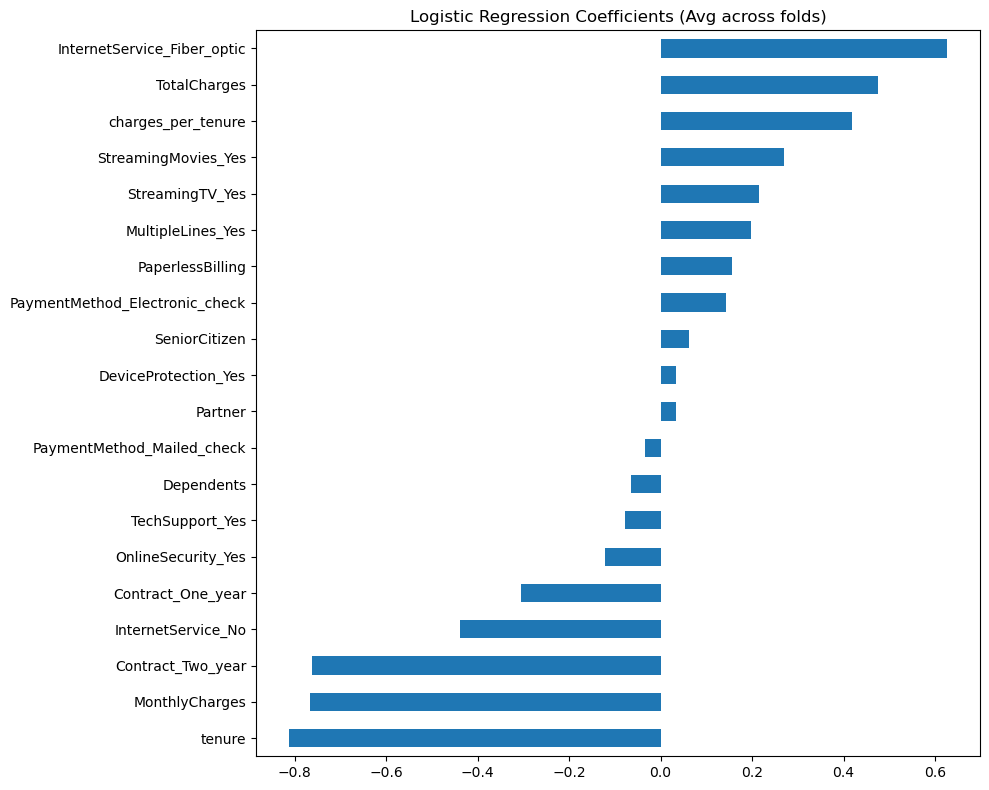

In [58]:
lr_importance = pd.DataFrame(
    {
        f'fold_{i}': m.coef_[0]
        for i, m in enumerate(lr_models)
    },
    index=X_train.columns
).mean(axis=1).sort_values(key=abs, ascending=False)

lr_importance.head(20).sort_values().plot(
    kind='barh',
    figsize=(10,8),
    title='Logistic Regression Coefficients (Avg across folds)'
)

plt.tight_layout()
plt.show()

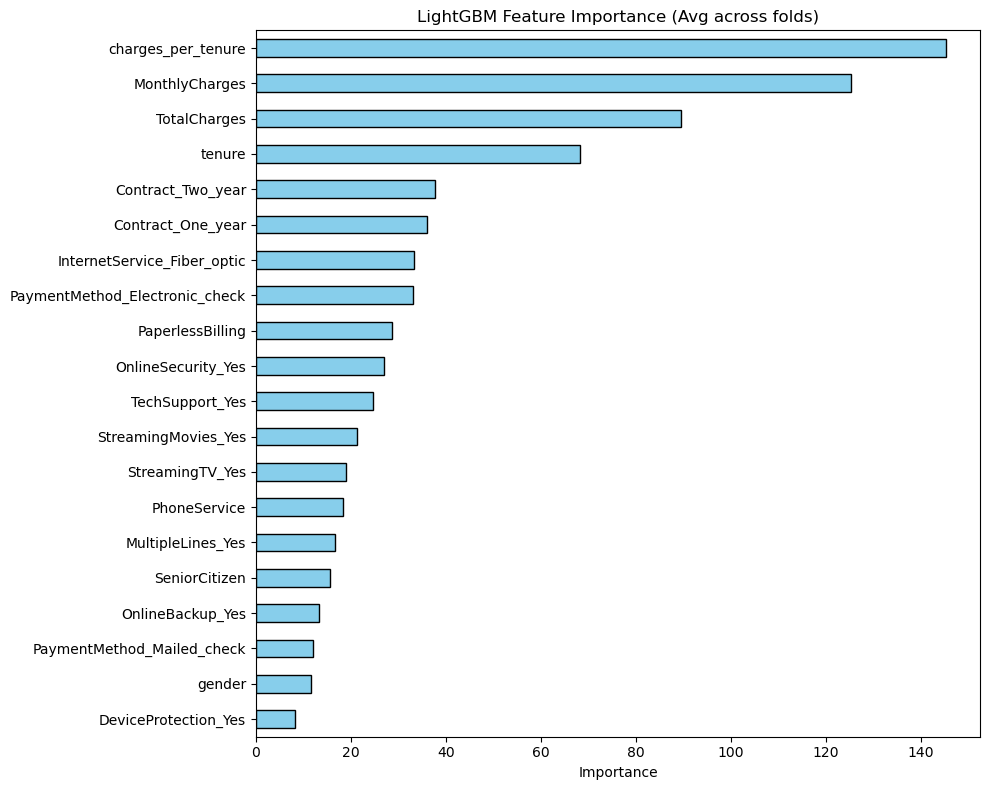

In [59]:
#Feature Importance

feature_importance = pd.DataFrame(
    {
        f'fold_{i}': m.feature_importances_
        for i, m in enumerate(lgbm_models)
    },
    index=X_train.columns
).mean(axis=1).sort_values(ascending=False)

feature_importance.head(20).sort_values().plot(
    kind='barh',
    figsize=(10,8),
    color='skyblue',
    edgecolor='black',
    title='LightGBM Feature Importance (Avg across folds)'
)

plt.xlabel("Importance")
plt.tight_layout()
plt.show()

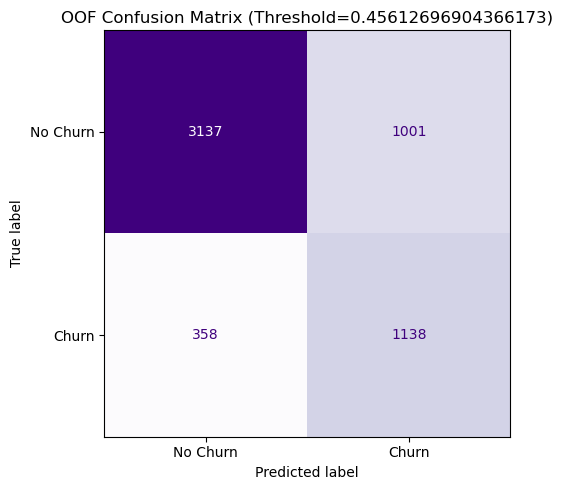

              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.82      4138
       Churn       0.53      0.76      0.63      1496

    accuracy                           0.76      5634
   macro avg       0.71      0.76      0.72      5634
weighted avg       0.80      0.76      0.77      5634



In [60]:
#Confusion Matrix for LightGBM

precision, recall, thresholds = precision_recall_curve(y_train, oof_preds)
f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

oof_binary = (oof_preds >= best_threshold).astype(int)

cm = confusion_matrix(y_train, oof_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])

fig, ax = plt.subplots(figsize=(6,5))
disp.plot(cmap='Purples', ax=ax, colorbar=False)
plt.title(f"OOF Confusion Matrix (Threshold={best_threshold})")
plt.tight_layout()
plt.show()

print(classification_report(y_train, oof_binary, target_names=['No Churn', 'Churn']))

## Final Model Evaluation
Final models are retrained on the full training set and evaluated on the held-out 
test set. LightGBM uses the average best iteration from CV folds to avoid overfitting.

In [61]:
# Logistic Regression final model
lr_final = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='liblinear',
    random_state=RANDOM_STATE
)
lr_final.fit(X_train_scaled, y_train)

#Random Forest final model
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)

best_n = int(np.mean([m.best_iteration_ for m in lgbm_models]))

# LightGBM final model
lgbm_final = lgb.LGBMClassifier(
    n_estimators=best_n,
    learning_rate=0.05,
    num_leaves=31,
    colsample_bytree=0.8,
    subsample=0.8,
    random_state=RANDOM_STATE
)

lgbm_final.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1496, number of negative: 4138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000470 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 880
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265531 -> initscore=-1.017418
[LightGBM] [Info] Start training from score -1.017418


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,27
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


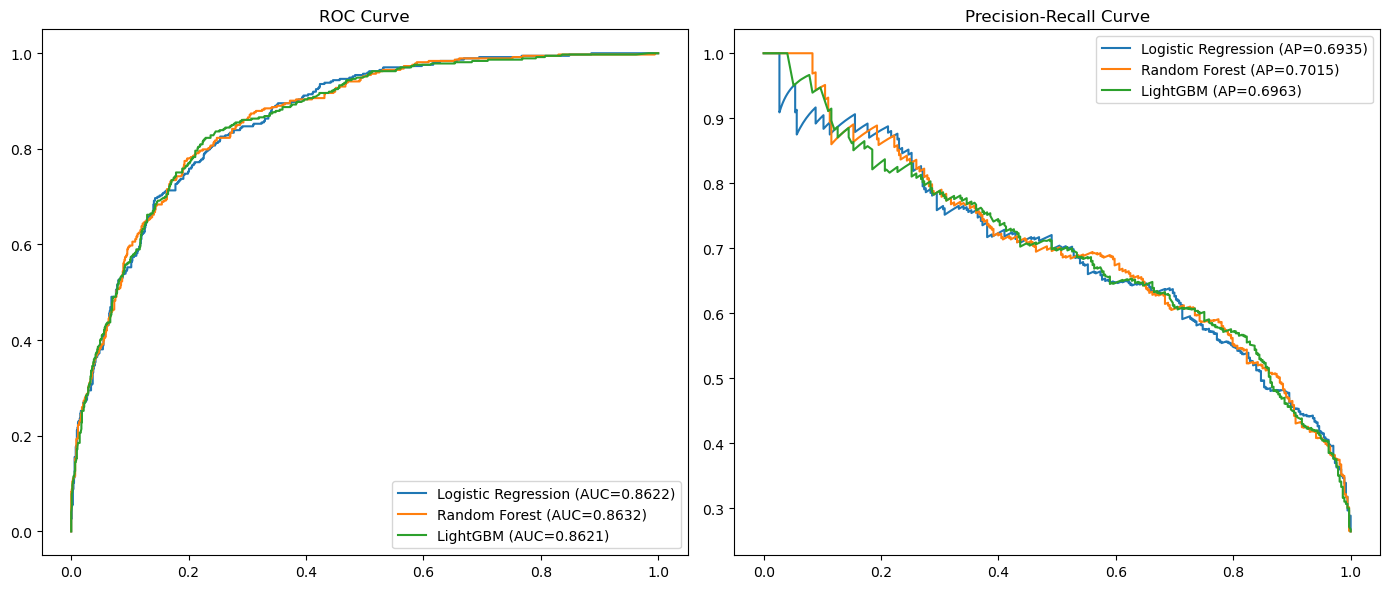

In [62]:
# ROC curves

lr_probs = lr_final.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf_final.predict_proba(X_test)[:, 1]
lgbm_probs = lgbm_final.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models = [
    ("Logistic Regression", lr_probs),
    ("Random Forest", rf_probs),
    ("LightGBM", lgbm_probs),
]

for name, probs in models:
    fpr, tpr, _ = roc_curve(y_test, probs)
    precision, recall, _ = precision_recall_curve(y_test, probs)

    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, probs):.4f})")
    axes[1].plot(recall, precision, label=f"{name} (AP={average_precision_score(y_test, probs):.4f})")

axes[0].set_title("ROC Curve")
axes[1].set_title("Precision-Recall Curve")

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/ROC_&_PR_Curves.png', dpi=150, bbox_inches='tight')
plt.show()


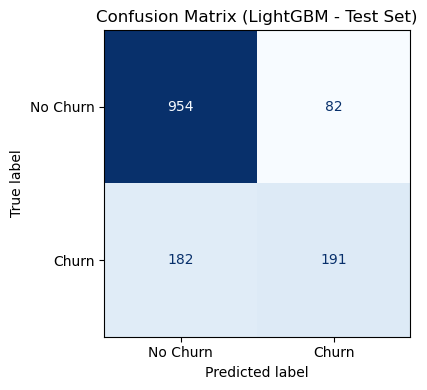

In [63]:
# Choose best model
best_probs = lgbm_final.predict_proba(X_test)[:, 1]
best_preds = (best_probs >= best_threshold).astype(int)

cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)

plt.title("Confusion Matrix (LightGBM - Test Set)")
plt.tight_layout()
plt.savefig('../outputs/figures/LightGBM_ConfusioMatrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Model Interpretability (SHAP)
SHAP (SHapley Additive exPlanations) shows the contribution of each feature to 
individual predictions. This helps explain *why* the model flags a customer as 
likely to churn.

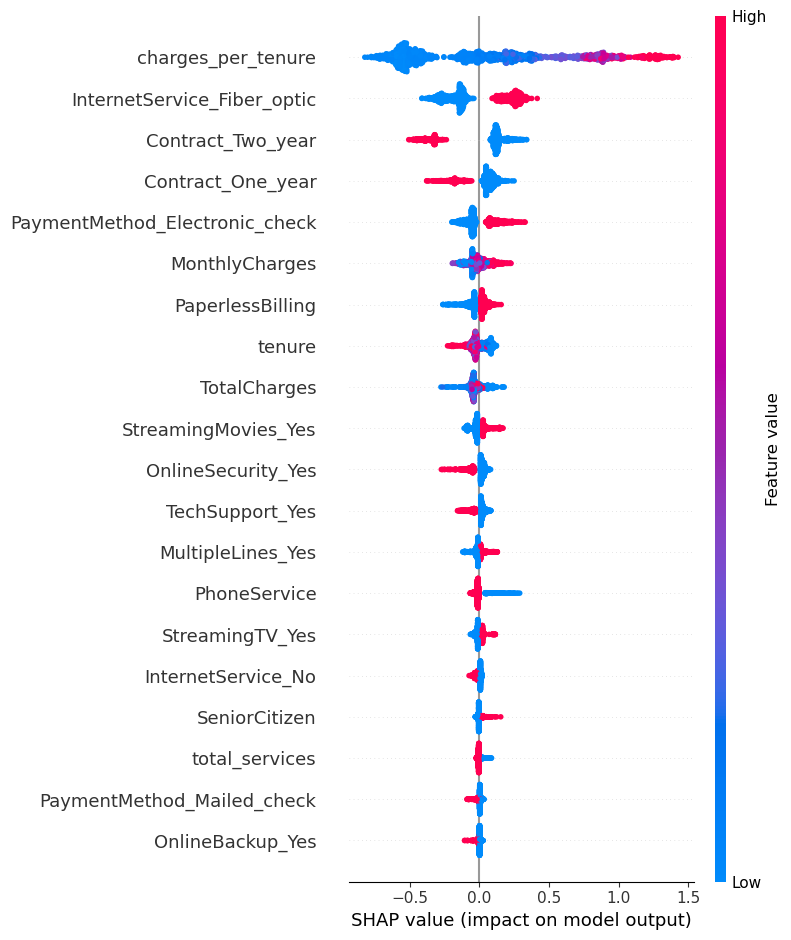

In [64]:
explainer = shap.TreeExplainer(lgbm_final)
shap_values = explainer.shap_values(X_test)

# Handle both old SHAP (list) and new SHAP (single array)
if isinstance(shap_values, list):
    sv = shap_values[1]  # old: list of [neg_class, pos_class]
else:
    sv = shap_values     # new: single 2D array already for positive class

plt.savefig('../outputs/figures/ShapSummary.png', bbox_inches='tight', dpi=150)
shap.summary_plot(sv, X_test)

## Business Insights

| Driver | Finding | Recommended Action |
|---|---|---|
| Contract type | Month-to-month customers churn at 3x the rate of 2-year contracts | Offer discounts to upgrade to annual contracts |
| Tenure | 50% of churners leave within the first 12 months | Prioritise onboarding for new customers |
| Monthly Charges | Churners pay ~$15 more/month on average | Flag high-charge, low-tenure customers for proactive outreach |
| Internet Service | Fibre optic customers churn at ~42% vs DSL at ~19% | Investigate fibre service quality issues |

In [65]:
summary = pd.DataFrame([
    {"Model": "Logistic Regression", "CV ROC-AUC": np.mean(lr_scores), "CV Std": np.std(lr_scores), "Test ROC-AUC": roc_auc_score(y_test, lr_probs)},
    {"Model": "Random Forest",       "CV ROC-AUC": np.mean(rf_scores), "CV Std": np.std(rf_scores), "Test ROC-AUC": roc_auc_score(y_test, rf_probs)},
    {"Model": "LightGBM",            "CV ROC-AUC": np.mean(lgbm_scores), "CV Std": np.std(lgbm_scores), "Test ROC-AUC": roc_auc_score(y_test, lgbm_probs)},
])
display(summary.sort_values("CV ROC-AUC", ascending=False))

,Model,CV ROC-AUC,CV Std,Test ROC-AUC
0,Logistic Regression,0.844194,0.012966,0.862154
2,LightGBM,0.841184,0.017926,0.862148
1,Random Forest,0.839443,0.015726,0.863163


In [66]:
#Saving final model and scalar
joblib.dump(lgbm_final, '../models/lgbm_final.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

#Saving RF and LR
joblib.dump(rf_final, '../models/rf_final.pkl')
joblib.dump(lr_final, '../models/lr_final.pkl')

print("Models saved successfully!")

Models saved successfully!


## Conclusion

LightGBM outperformed both baseline models with a CV ROC-AUC of 0.841184 and Test 
ROC-AUC of 0.862148. The optimised classification threshold of ~0.456 improves recall 
on the minority churn class, which is the business-critical direction.

### Limitations
- Dataset is static; a production model would need retraining as customer behaviour shifts
- No hyperparameter tuning was performed — GridSearchCV or Optuna could further improve results

### Next Steps
- Deploy model as a REST API using FastAPI
- Add hyperparameter tuning with Optuna
- Explore customer lifetime value weighting in the loss function